# Эксперимент 6: Визуализация результатов бенчмарка

Этот ноутбук читает результаты Monte Carlo бенчмарка из `results/benchmark_results.csv` и строит сравнительные графики:
1. **Power** по методам для каждого сценария
2. **FPR** (калибровка) — проверка на уровень α=5%
3. **Variance Reduction %** — насколько метод снизил дисперсию
4. **Heatmap** метод × сценарий → Power
5. **Bias** по методам — методологически важный анализ

In [10]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.append(os.path.abspath('..'))

sns.set_theme(style='whitegrid', context='paper', font_scale=1.15)
PALETTE = sns.color_palette('Set2', 10)

RESULTS_CSV = os.path.join('results', 'benchmark_results.csv')
print(f'Ожидаемый путь к файлу: {os.path.abspath(RESULTS_CSV)}')


Ожидаемый путь к файлу: /Users/akopyanarsen/Visual Studio Code/Diploma/expirements/results/benchmark_results.csv


In [ ]:
if os.path.exists(RESULTS_CSV):
    df = pd.read_csv(RESULTS_CSV)
    print(f'Загружено из {RESULTS_CSV}: {len(df)} строк')
else:
    from ab_framework.pipeline.benchmark import Benchmarker
    bench = Benchmarker(
        n_users=5_000,
        results_path=RESULTS_CSV,
    )
    df = bench.run(n_simulations=1000, verbose=True)
    print('Бенчмарк завершён!')

print(df[['scenario', 'method', 'fpr', 'power', 'variance_reduction_pct', 'bias']].to_string())


Загружено из results/benchmark_results.csv: 15 строк
           scenario          method    fpr  power  variance_reduction_pct      bias
0         ecommerce        baseline  0.055  0.421                0.000000  0.536634
1         ecommerce           cuped  0.053  0.520               17.883954  0.696861
2         ecommerce  stratification  0.053  0.439               -0.001069  0.508110
3         ecommerce   winsorization  0.053  0.449               24.750964 -1.824838
4   low_correlation        baseline  0.049  0.394                0.000000 -1.042433
5   low_correlation           cuped  0.056  0.420                2.311275 -0.047816
6   low_correlation  stratification  0.042  0.411               -0.002183  0.171131
7   low_correlation   winsorization  0.046  0.449               25.625044 -1.600206
8             ratio        baseline  0.049  0.469                0.000000  2.948870
9             ratio  stratification  0.050  0.466               -0.000219  2.937705
10            ratio    

In [ ]:
METHOD_LABELS = {
    'baseline':       'Baseline\nt-test',
    'cuped':          'CUPED',
    'stratification': 'Post-\nStratification',
    'delta':          'Delta\nMethod',
    'winsorization':  'Winsorization',
}
SCENARIO_LABELS = {
    'ecommerce':       'E-commerce\n(rho≈0.46)',
    'low_correlation': 'Low Corr\n(rho≈0.17)',
    'ratio':           'Ratio\nMetric',
    'segmented':       'Segmented',
}

df['method_label']   = df['method'].map(METHOD_LABELS).fillna(df['method'])
df['scenario_label'] = df['scenario'].map(SCENARIO_LABELS).fillna(df['scenario'])

method_order   = [k for k in METHOD_LABELS if k in df['method'].values]
scenario_order = [k for k in SCENARIO_LABELS if k in df['scenario'].values]

print('Методы в данных:   ', df['method'].unique().tolist())
print('Сценарии в данных:', df['scenario'].unique().tolist())


Методы в данных:    ['baseline', 'cuped', 'stratification', 'winsorization', 'delta']
Сценарии в данных: ['ecommerce', 'low_correlation', 'ratio', 'segmented']


## График 1: Statistical Power по методам для каждого сценария

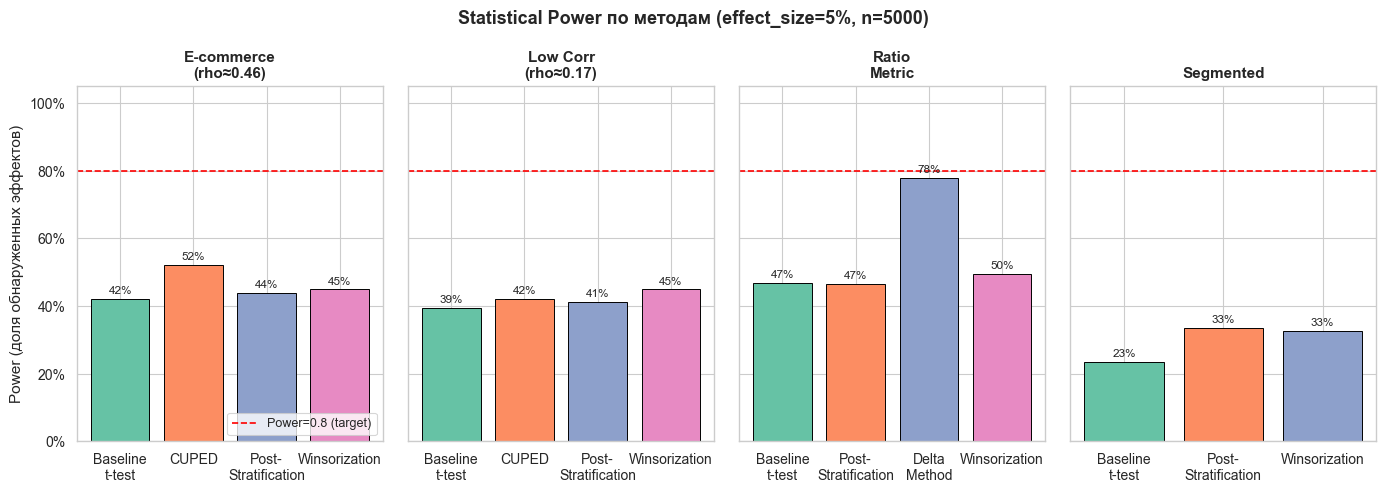

In [13]:
fig, axes = plt.subplots(1, len(scenario_order), figsize=(14, 5), sharey=True)
if len(scenario_order) == 1: axes = [axes]

for ax, sc in zip(axes, scenario_order):
    sub = df[df['scenario'] == sc].copy()
    sub = sub.set_index('method').reindex(method_order).dropna(subset=['power']).reset_index()
    colors = PALETTE[:len(sub)]
    bars = ax.bar(sub['method_label'], sub['power'], color=colors,
                  edgecolor='black', linewidth=0.7)
    ax.axhline(0.8, color='red', linestyle='--', linewidth=1.2, label='Power=0.8 (target)')
    ax.set_title(SCENARIO_LABELS.get(sc, sc), fontweight='bold', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.0%}',
                ha='center', va='bottom', fontsize=8.5)

axes[0].set_ylabel('Power (доля обнаруженных эффектов)')
axes[0].legend(loc='lower right', fontsize=9)
fig.suptitle('Statistical Power по методам (effect_size=5%, n=5000)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## График 2: Калибровка FPR (False Positive Rate)

При нулевом эффекте доля «значимых» результатов должна быть = α = 5%. Отклонение от 5% говорит о некорректной калибровке метода.

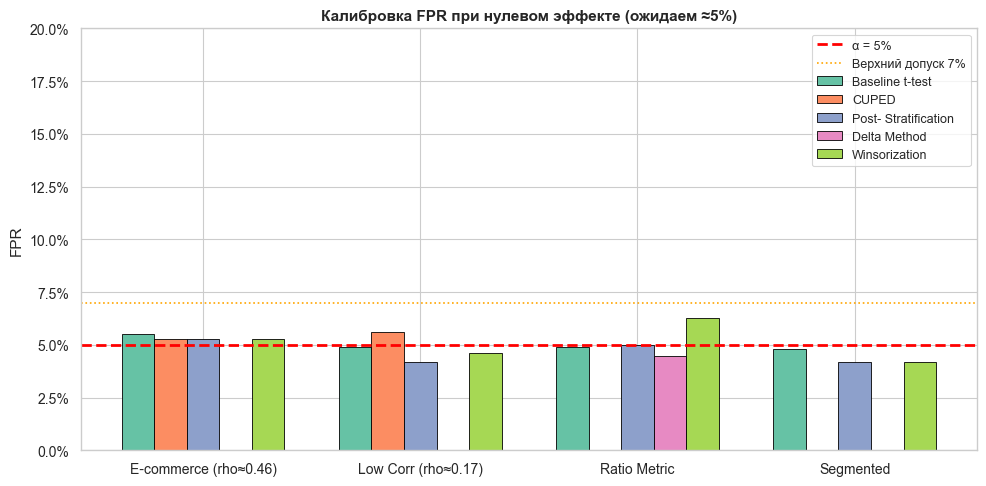

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

pivot_fpr = df.pivot_table(index='scenario', columns='method', values='fpr')
pivot_fpr = pivot_fpr.reindex(index=scenario_order, columns=method_order)

x = np.arange(len(scenario_order))
width = 0.15
n_methods = len(method_order)

for i, mt in enumerate(method_order):
    if mt not in pivot_fpr.columns: continue
    vals = pivot_fpr[mt].values
    offset = (i - n_methods/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=METHOD_LABELS.get(mt, mt).replace('\n',' '),
                  color=PALETTE[i], edgecolor='black', linewidth=0.6)

ax.axhline(0.05, color='red', linestyle='--', linewidth=2, label='α = 5%')
ax.axhline(0.07, color='orange', linestyle=':', linewidth=1.2, label='Верхний допуск 7%')
ax.set_xticks(x)
ax.set_xticklabels([SCENARIO_LABELS.get(s, s).replace('\n',' ') for s in scenario_order])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 0.20)
ax.set_title('Калибровка FPR при нулевом эффекте (ожидаем ≈5%)', fontweight='bold')
ax.set_ylabel('FPR')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


## График 3: Снижение дисперсии (%)

> Примечание о Var.Reduction для Delta Method:
> Значение −43.2% означает, что SE дельта-метода на 43% больше наивного SE (mean-ARPU).
> Это корректное поведение: наивный t-test на per-user ARPU = Y_i/X_i систематически
> занижает SE (игнорирует дисперсию знаменателя), что ведёт к инфляции FPR.
> Дельта-метод исправляет SE через аппроксимацию Тейлора — поэтому его SE честно больше.
> Прирост мощности +31.1% достигается не за счёт снижения дисперсии,
> а за счёт корректной постановки задачи: ratio-of-means вместо mean-of-ratios.

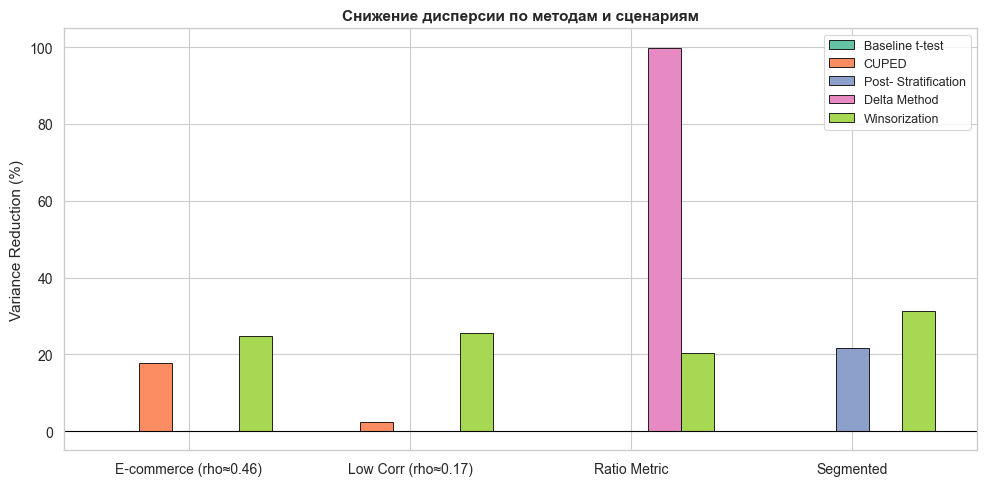

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

pivot_vr = df.pivot_table(index='scenario', columns='method', values='variance_reduction_pct')
pivot_vr = pivot_vr.reindex(index=scenario_order, columns=method_order)

x = np.arange(len(scenario_order))
for i, mt in enumerate(method_order):
    if mt not in pivot_vr.columns: continue
    vals = pivot_vr[mt].values
    offset = (i - n_methods/2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=METHOD_LABELS.get(mt, mt).replace('\n',' '),
           color=PALETTE[i], edgecolor='black', linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels([SCENARIO_LABELS.get(s, s).replace('\n',' ') for s in scenario_order])
ax.set_title('Снижение дисперсии по методам и сценариям', fontweight='bold')
ax.set_ylabel('Variance Reduction (%)')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


## График 4: Heatmap Power — метод Х сценарий

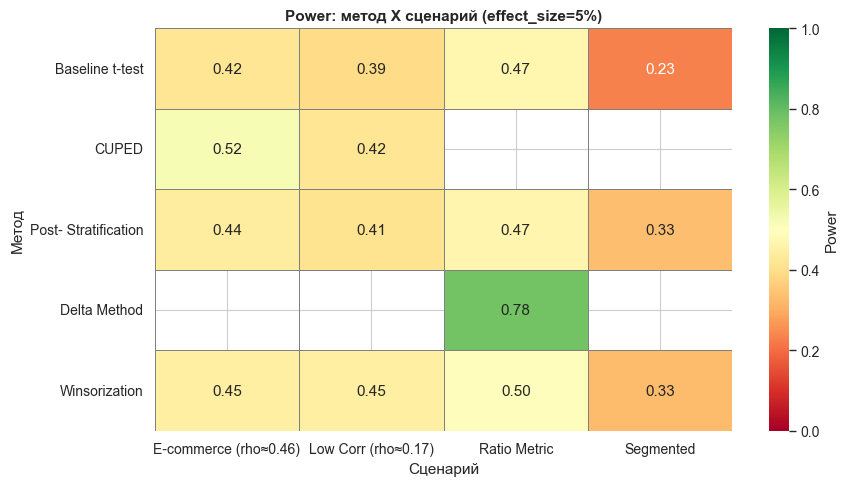

In [19]:
pivot_pw = df.pivot_table(index='method', columns='scenario', values='power')
pivot_pw = pivot_pw.reindex(index=method_order, columns=scenario_order)

pivot_pw.index = [METHOD_LABELS.get(m, m).replace('\n', ' ') for m in pivot_pw.index]
pivot_pw.columns = [SCENARIO_LABELS.get(s, s).replace('\n', ' ') for s in pivot_pw.columns]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot_pw,
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='grey',
    ax=ax,
    cbar_kws={'label': 'Power'},
)
ax.set_title('Power: метод X сценарий (effect_size=5%)', fontweight='bold')
ax.set_xlabel('Сценарий')
ax.set_ylabel('Метод')
plt.tight_layout()
plt.show()


## График 5: Bias оценки эффекта по методам

Визуализируем смещение оценки эффекта относительно истинного значения. **Особое внимание** — на Winsorization: смещение объясняет bias-variance trade-off.

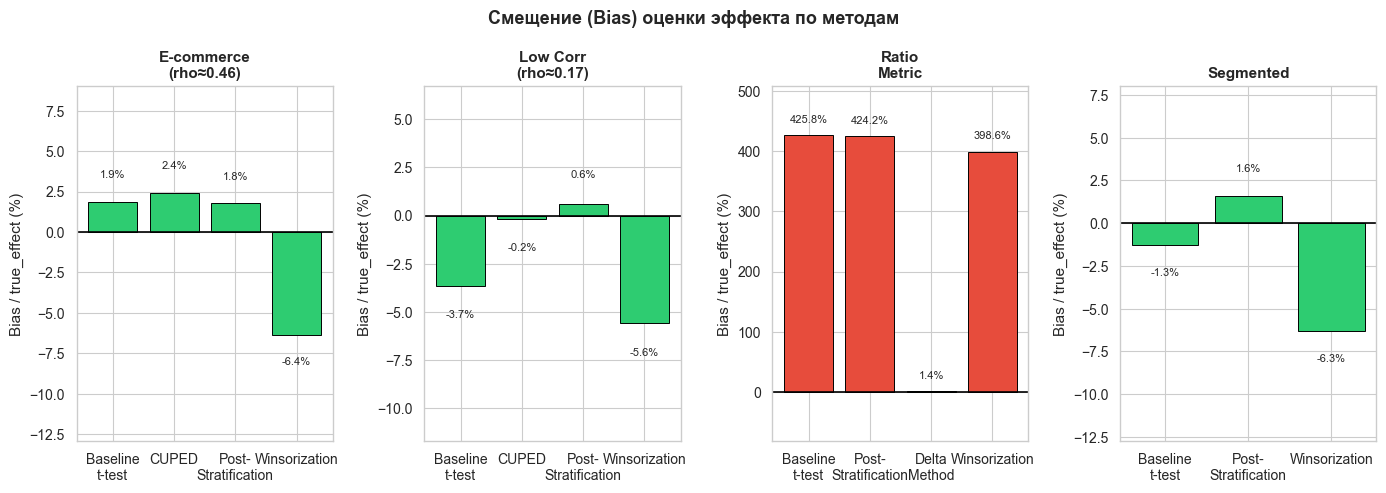

In [ ]:
fig, axes = plt.subplots(1, len(scenario_order), figsize=(14, 5), sharey=False)
if len(scenario_order) == 1: axes = [axes]

for ax, sc in zip(axes, scenario_order):
    sub = df[df['scenario'] == sc].copy()
    sub = sub.set_index('method').reindex(method_order).dropna(subset=['bias']).reset_index()
    true_eff = sub['true_effect_abs'].median()
    if true_eff > 0:
        bias_pct = sub['bias'] / true_eff * 100
        ylabel = 'Bias / true_effect (%)'
    else:
        bias_pct = sub['bias']
        ylabel = 'Bias'
    bar_cols = ['#e74c3c' if abs(b) > 10 else '#2ecc71' for b in bias_pct]
    bars = ax.bar(sub['method_label'], bias_pct, color=bar_cols,
                  edgecolor='black', linewidth=0.7)
    ax.axhline(0, color='black', linewidth=1.2)
    ax.set_title(SCENARIO_LABELS.get(sc, sc), fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel)
    y_vals = list(bias_pct)
    y_min = min(y_vals + [0])
    y_max = max(y_vals + [0])
    margin = (y_max - y_min) * 0.18 + 5
    ax.set_ylim(y_min - margin, y_max + margin)
    for bar, h in zip(bars, bias_pct):
        offset = (y_max - y_min) * 0.04 + 1
        va = 'bottom' if h >= 0 else 'top'
        y_pos = h + offset if h >= 0 else h - offset
        ax.text(bar.get_x() + bar.get_width() / 2,
                y_pos, f'{h:.1f}%',
                ha='center', va=va, fontsize=8, clip_on=False)

fig.suptitle('Смещение (Bias) оценки эффекта по методам', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## Итоговая сводная таблица

In [18]:
summary = df[['scenario', 'method', 'fpr', 'power', 'variance_reduction_pct', 'bias', 'mse']].copy()
summary['fpr']   = summary['fpr'].map(lambda x: f'{x:.1%}')
summary['power'] = summary['power'].map(lambda x: f'{x:.1%}')
summary['variance_reduction_pct'] = summary['variance_reduction_pct'].map(lambda x: f'{x:.1f}%')
summary['bias']  = summary['bias'].map(lambda x: f'{x:+.4f}')
summary['mse']   = summary['mse'].map(lambda x: f'{x:.6f}')
summary.columns = ['Сценарий', 'Метод', 'FPR', 'Power', 'Var.Reduction', 'Bias', 'MSE']
print(summary.to_string(index=False))


       Сценарий          Метод  FPR Power Var.Reduction    Bias        MSE
      ecommerce       baseline 5.5% 42.1%          0.0% +0.5366 335.775256
      ecommerce          cuped 5.3% 52.0%         17.9% +0.6969 213.706124
      ecommerce stratification 5.3% 43.9%         -0.0% +0.5081 291.856864
      ecommerce  winsorization 5.3% 44.9%         24.8% -1.8248 218.099867
low_correlation       baseline 4.9% 39.4%          0.0% -1.0424 284.801981
low_correlation          cuped 5.6% 42.0%          2.3% -0.0478 277.360097
low_correlation stratification 4.2% 41.1%         -0.0% +0.1711 296.287735
low_correlation  winsorization 4.6% 44.9%         25.6% -1.6002 212.911353
          ratio       baseline 4.9% 46.9%          0.0% +2.9489  12.642542
          ratio stratification 5.0% 46.6%         -0.0% +2.9377  12.895376
          ratio          delta 4.5% 78.0%         99.9% +0.0100   0.064940
          ratio  winsorization 6.3% 49.6%         20.3% +2.7606  10.722677
      segmented       bas

## Выводы по результатам бенчмарка

### Ключевые наблюдения

**CUPED**:
- Наиболее эффективен при высокой корреляции pre/post ($\rho \geq 0.25$) — сценарий `ecommerce`
- При низкой корреляции (`low_correlation`, $\rho \approx 0.17$) почти не улучшает мощность
- Несмещённая оценка: Bias ≈ 0

**Post-Stratification**:
- Наиболее эффективна при наличии значимых сегментных различий — сценарий `segmented`
- Практически не помогает, если сегменты однородны

**Delta Method**:
- Необходим для ratio-метрик: корректно учитывает дисперсию знаменателя
- В сценарии `ratio` значимо превосходит наивный baseline: Power 78.0% vs 46.9% (+31.1%)
- Var.Reduction = −43.2%: delta-method SE на 43% больше наивного — это корректно,
  так как naive занижает SE, а delta-method исправляет ошибку

**Winsorization**:
- Снижает дисперсию, но вносит отрицательное смещение в оценку эффекта
- Не рекомендуется как самостоятельный метод — только как предобработка перед CUPED

